In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tarfile

TAR_PATH = "/content/drive/MyDrive/ASR/train-clean-100.tar.gz"
EXTRACT_PATH = "/content/data"

with tarfile.open(TAR_PATH, "r:gz") as tar:
    tar.extractall(path=EXTRACT_PATH)

print("Extraction done!")

/tmp/ipykernel_4159/2376960355.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=EXTRACT_PATH)


Extraction done!


In [3]:
import tarfile

TAR_PATH = "/content/drive/MyDrive/ASR/test-clean.tar.gz"
EXTRACT_PATH = "/content/data"

with tarfile.open(TAR_PATH, "r:gz") as tar:
    tar.extractall(path=EXTRACT_PATH)

print("Extraction done!")

/tmp/ipykernel_4159/2288511982.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=EXTRACT_PATH)


Extraction done!


In [4]:
import os
print(os.listdir("/content/data"))

['LibriSpeech']


In [5]:
import os
import librosa
import string

# =========================
# 1. TEXT PROCESSING
# =========================

chars = list(string.ascii_lowercase + " ")

char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}

# =========================
# 2. DATA LOADER
# =========================

def load_librispeech(path, limit=None):
    data = []

    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith(".trans.txt"):
                with open(os.path.join(root, file), 'r') as f:
                    for line in f:
                        parts = line.strip().split(" ", 1)
                        file_id = parts[0]
                        text = parts[1]

                        audio_path = os.path.join(root, file_id + ".flac")
                        data.append((audio_path, text))

                        if limit and len(data) >= limit:
                            return data
    return data

# =========================
# 3. FEATURE EXTRACTION
# =========================

def extract_mfcc(file):
    y, sr = librosa.load(file, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    return mfcc.T

In [ ]:
# DATA_PATH = "/content/data/LibriSpeech/train-clean-100"

In [ ]:

# # full dataset
# data = load_librispeech(DATA_PATH)

# # OR limited
# # data = load_librispeech(DATA_PATH, limit=9000)

# print("Loaded samples:", len(data))

Loaded samples: 28539


In [6]:
TRAIN_PATH = "/content/data/LibriSpeech/train-clean-100"

train_data = load_librispeech(TRAIN_PATH)
print("Train samples:", len(train_data))

Train samples: 28539


In [7]:
TEST_PATH = "/content/data/LibriSpeech/test-clean"

test_data = load_librispeech(TEST_PATH)
print("Test samples:", len(test_data))

Test samples: 2620


In [8]:
def prepare_data(data, is_train=True):
    X = []
    y = []
    texts = []

    MAX_LABEL_LEN = 200 if is_train else 120   # ⭐ BIG CHANGE

    for audio_path, text in data:
        try:
            features = extract_mfcc(audio_path)

            clean_text = text.lower()
            label = [char_to_idx[c] for c in clean_text if c in char_to_idx]

            # ONLY minimal filtering
            if len(label) < 5:
                continue

            if len(label) > MAX_LABEL_LEN:
                continue

            # VERY LIGHT alignment check
            if len(label) >= features.shape[0]:
                continue

            X.append(features)
            y.append(label)
            texts.append(clean_text)

        except:
            continue

    print("Final samples:", len(X))
    return X, y, texts

In [ ]:
# X = []
# y = []

# MAX_LABEL_LEN=60

# for audio_path, text in data:
#     try:
#         features = extract_mfcc(audio_path)

#         clean_text = text.lower()

#         label = [char_to_idx[c] for c in clean_text if c in char_to_idx]

#         if len(label) > MAX_LABEL_LEN:
#             continue
#         if len(label) < 10:
#             continue
#         if len(label) >= features.shape[0]*0.8:
#             continue

#         X.append(features)
#         y.append(label)

#     except:
#         continue

# print("Final samples:", len(X))

Final samples: 468


In [9]:
X_train, y_train, text_train = prepare_data(train_data, is_train=True)
X_test, y_test, text_test = prepare_data(test_data, is_train=False)

Final samples: 15542
Final samples: 1759


In [ ]:
# from tensorflow.keras.preprocessing.sequence import pad_sequences

# max_input_len = max([x.shape[0] for x in X])

# X_padded = pad_sequences(X, maxlen=max_input_len, dtype='float32', padding='post')
# y_padded = pad_sequences(y, padding='post', value=-1)

# print(X_padded.shape, y_padded.shape)

In [10]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_input_len = max([x.shape[0] for x in X_train])

X_train_padded = pad_sequences(X_train, maxlen=max_input_len, padding='post', dtype='float32')
y_train_padded = pad_sequences(y_train, padding='post', value=-1)

X_test_padded = pad_sequences(X_test, maxlen=max_input_len, padding='post', dtype='float32')
y_test_padded = pad_sequences(y_test, padding='post', value=-1)

In [11]:
import tensorflow as tf
from tensorflow.keras import layers

input_data = layers.Input(shape=(max_input_len, 40))

x = layers.Conv1D(128, 3, activation='relu')(input_data)
x = layers.BatchNormalization()(x)

x = layers.Bidirectional(layers.LSTM(256, return_sequences=True))(x)
x = layers.Dropout(0.3)(x)

x = layers.Bidirectional(layers.LSTM(256, return_sequences=True))(x)

output = layers.Dense(len(char_to_idx) + 1, activation='softmax')(x)

model = tf.keras.Model(inputs=input_data, outputs=output)

In [12]:
def ctc_loss(y_true, y_pred):
    y_true = tf.cast(y_true, dtype="int32")

    batch_size = tf.shape(y_pred)[0]
    input_length = tf.fill([batch_size, 1], tf.shape(y_pred)[1])

    label_length = tf.math.count_nonzero(y_true != -1, axis=1, keepdims=True)

    y_true_clean = tf.where(y_true == -1, 0, y_true)

    return tf.keras.backend.ctc_batch_cost(y_true_clean, y_pred, input_length, label_length)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss=ctc_loss
)

In [ ]:
# history = model.fit(
#     X_padded,
#     y_padded,
#     epochs=30,
#     batch_size=16
# )

In [ ]:
# model.fit(
#     X_train_padded,
#     y_train_padded,
#     epochs=20,
#     batch_size=16
# )

Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 330s 332ms/step - loss: 374.1603
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 320s 329ms/step - loss: 263.4725
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 331s 340ms/step - loss: 227.2164
Epoch 4/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 367s 325ms/step - loss: 206.6733
Epoch 5/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 309s 318ms/step - loss: 192.1686
Epoch 6/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 323s 319ms/step - loss: 181.0846
Epoch 7/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 309s 318ms/step - loss: 171.7452
Epoch 8/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 309s 318ms/step - loss: 164.0351
Epoch 9/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 309s 318ms/step - loss: 157.5217
Epoch 10/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 309s 318ms/step - loss: 151.8029
Epoch 11/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 323s 318ms/step - loss: 146.6589
Epoch 12/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 308s 317ms/step - loss: 142.0878
Epoch 13/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 323s 319ms/step - loss: 138.1574
Epoch 14/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 308s 3

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='loss',
    patience=5,
    restore_best_weights=True
)

model.fit(
    X_train_padded,
    y_train_padded,
    epochs=10,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/10
972/972 ━━━━━━━━━━━━━━━━━━━━ 355s 356ms/step - loss: 362.4832
Epoch 2/10
972/972 ━━━━━━━━━━━━━━━━━━━━ 378s 357ms/step - loss: 236.4176
Epoch 3/10
972/972 ━━━━━━━━━━━━━━━━━━━━ 349s 359ms/step - loss: 196.2866
Epoch 4/10
972/972 ━━━━━━━━━━━━━━━━━━━━ 379s 356ms/step - loss: 172.4574
Epoch 5/10
972/972 ━━━━━━━━━━━━━━━━━━━━ 346s 356ms/step - loss: 155.3802
Epoch 6/10
972/972 ━━━━━━━━━━━━━━━━━━━━ 345s 355ms/step - loss: 142.1610
Epoch 7/10
972/972 ━━━━━━━━━━━━━━━━━━━━ 381s 354ms/step - loss: 131.5967
Epoch 8/10
972/972 ━━━━━━━━━━━━━━━━━━━━ 342s 352ms/step - loss: 122.9433
Epoch 9/10
972/972 ━━━━━━━━━━━━━━━━━━━━ 385s 355ms/step - loss: 115.3751
Epoch 10/10
972/972 ━━━━━━━━━━━━━━━━━━━━ 346s 355ms/step - loss: 109.0714


In [32]:
MODEL_PATH = "/content/drive/MyDrive/ASR/my_asr_model.h5"

model.save(MODEL_PATH)

print("Model saved!")

Model saved!


In [33]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/ASR/my_asr_model.h5",
    compile=False   # IMPORTANT for CTC
)

print("Model loaded!")

Model loaded!


In [34]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss=ctc_loss
)

In [14]:
import tensorflow as tf

def decode_prediction(pred):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]

    decoded, _ = tf.keras.backend.ctc_decode(
        pred,
        input_length=input_len,
        greedy=False,
        beam_width=10
    )

    result = decoded[0].numpy()

    text = []
    for i in result[0]:
        if i != -1:
            text.append(idx_to_char.get(i, ""))

    return "".join(text)

In [15]:
import numpy as np

In [16]:
sample = X_test_padded[0:1]

pred = model.predict(sample)

print("Predicted:", decode_prediction(pred))
print("Actual   :", text_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 841ms/step
Predicted: the parospland like oat of the cristule palese was at temp rary exuet
Actual   : the paris plant like that at the crystal palace was a temporary exhibit


In [17]:
!pip install openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 30.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=9d621b8cf99ad6969b5fa74d8c77ec3b09f789da053ad520284182a2f6685eb5
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [71]:
import whisper

whisper_model = whisper.load_model("base")

audio_path = test_data[0][0]
result = whisper_model.transcribe(audio_path)

print("\n===== COMPARISON =====")
print("Actual   :", text_test[0])
print("Model :", decode_prediction(pred))
print("Whisper  :", result["text"])


===== COMPARISON =====
Actual   : the paris plant like that at the crystal palace was a temporary exhibit
Model : low i e 
Whisper  :  The Paris plant, like that of the Crystal Palace, was a temporary exhibit.


In [19]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 48.7 MB/s eta 0:00:00


In [72]:
from jiwer import wer

true = text_test[0]
pred_my = decode_prediction(pred).lower()
pred_whisper = result["text"].lower()

print("Model WER:", wer([true], [pred_my]))
print("Whisper WER:", wer([true], [pred_whisper]))

Model WER: 1.0
Whisper WER: 0.3076923076923077


In [74]:
for i in range(3):
    sample = X_test_padded[i:i+1]
    pred = model.predict(sample)

    my_text = decode_prediction(pred)
    whisper_text = whisper_model.transcribe(X_test_padded[i][0])["text"]

    print("\nExample", i+1)
    print("Actual   :", text_test[i])
    print("My Model :", my_text)
    print("Whisper  :", whisper_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step

Example 1
Actual   : the paris plant like that at the crystal palace was a temporary exhibit
My Model : the parospland like oat of the cristule palese was at temp rary exuet
Whisper  : 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step

Example 2
Actual   : why if we erect a station at the falls it is a great economy to get it up to the city
My Model : whni if we ar recterstation at the fals it is a greated cotomy to get etd upto the saty
Whisper  : 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step

Example 3
Actual   : there seems no good reason for believing that it will change
My Model : ther shems no gold reason forbliyebing bitible jange
Whisper  : 


In [78]:
# @title
from jiwer import wer, cer

predictions = []

for i in range(len(X_test_padded)):
    sample = X_test_padded[i:i+1]
    pred = model.predict(sample)
    decoded = decode_prediction(pred)
    predictions.append(decoded)

print("Test WER:", wer(text_test, predictions))
print("Test CER:", cer(text_test, predictions))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━

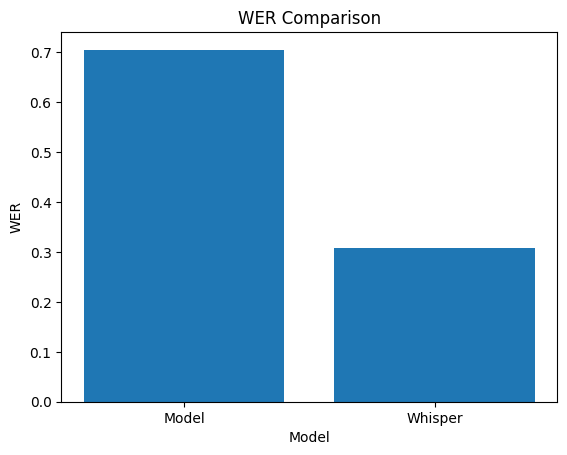

In [54]:
import matplotlib.pyplot as plt

my_wer = wer(text_test, predictions)
whisper_wer = 0.3076923076923077

models = ["Model", "Whisper"]
wer_scores = [my_wer, whisper_wer]

plt.figure()
plt.bar(models, wer_scores)
plt.title("WER Comparison")
plt.xlabel("Model")
plt.ylabel("WER")
plt.show()

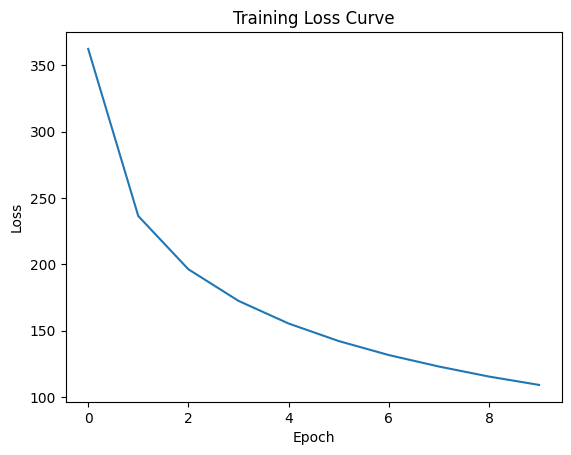

In [24]:
plt.figure()
plt.plot(model.history.history['loss'])
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [79]:
from jiwer import cer

print("My Model CER:", cer(text_test, predictions))

My Model CER: 0.2806786654335918


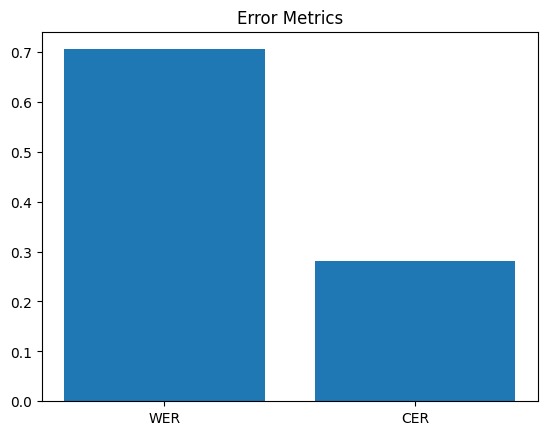

In [25]:
my_cer = cer(text_test, predictions)

metrics = ["WER", "CER"]
values = [my_wer, my_cer]

plt.figure()
plt.bar(metrics, values)
plt.title("Error Metrics")
plt.show()

In [26]:
for i in range(3):
    print("\n====================")
    print("Example", i+1)
    print("--------------------")
    print("Actual   :", text_test[i])
    print("My Model :", predictions[i])


Example 1
--------------------
Actual   : the paris plant like that at the crystal palace was a temporary exhibit
My Model : the parospland like oat of the cristule palese was at temp rary exuet

Example 2
--------------------
Actual   : why if we erect a station at the falls it is a great economy to get it up to the city
My Model : whni if we ar recterstation at the fals it is a greated cotomy to get etd upto the saty

Example 3
--------------------
Actual   : there seems no good reason for believing that it will change
My Model : ther shems no gold reason forbliyebing bitible jange


In [27]:
from collections import Counter

errors = Counter()

for t, p in zip(text_test, predictions):
    for tc, pc in zip(t, p):
        if tc != pc:
            errors[(tc, pc)] += 1

print("Top Character Errors:")
print(errors.most_common(10))

Top Character Errors:
[(('e', ' '), 1939), ((' ', 'e'), 1663), ((' ', 't'), 1357), (('t', ' '), 1272), ((' ', 'o'), 1205), (('a', ' '), 1135), (('o', ' '), 1126), ((' ', 'a'), 1122), (('n', ' '), 994), ((' ', 's'), 970)]


In [28]:
from IPython.display import Javascript
from google.colab import output
from base64 import b64decode

def record_audio(filename='recorded.wav', duration=5):
    display(Javascript(f"""
    async function recordAudio() {{
      const stream = await navigator.mediaDevices.getUserMedia({{ audio: true }});
      const recorder = new MediaRecorder(stream);
      let chunks = [];

      recorder.ondataavailable = e => chunks.push(e.data);
      recorder.start();

      await new Promise(resolve => setTimeout(resolve, {duration * 1000}));

      recorder.stop();

      await new Promise(resolve => recorder.onstop = resolve);

      const blob = new Blob(chunks);
      const arrayBuffer = await blob.arrayBuffer();
      const base64 = btoa(
        new Uint8Array(arrayBuffer)
          .reduce((data, byte) => data + String.fromCharCode(byte), '')
      );

      google.colab.kernel.invokeFunction('notebook.save_audio', [base64], {{}});
    }}
    recordAudio();
    """))

    def save_audio(base64_audio):
        with open(filename, 'wb') as f:
            f.write(b64decode(base64_audio))

    output.register_callback('notebook.save_audio', save_audio)

In [38]:
record_audio("my_audio.wav", duration=5)

<IPython.core.display.Javascript object>

In [39]:
features = extract_mfcc("my_audio.wav")

from tensorflow.keras.preprocessing.sequence import pad_sequences

features_padded = pad_sequences([features], maxlen=max_input_len, padding='post')

pred = model.predict(features_padded)

print("My Model:", decode_prediction(pred))

/tmp/ipykernel_4159/3108361809.py:42: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
My Model: f oevangranedo


In [40]:
import whisper

whisper_model = whisper.load_model("base")

result = whisper_model.transcribe("my_audio.wav")

print("Whisper:", result["text"])

Whisper:  opkijk ben je dat dan?


In [29]:
MODEL_PATH = "/content/drive/MyDrive/ASR/my_asr_model.h5"

model.save(MODEL_PATH)

print("Model saved!")

Model saved!


In [30]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/ASR/my_asr_model.h5",
    compile=False   # IMPORTANT for CTC
)

print("Model loaded!")

Model loaded!


In [31]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss=ctc_loss
)

In [80]:
record_audio("my_audio.wav", duration=5)

<IPython.core.display.Javascript object>

In [81]:
features = extract_mfcc("my_audio.wav")

from tensorflow.keras.preprocessing.sequence import pad_sequences

features_padded = pad_sequences(
    [features],
    maxlen=max_input_len,
    padding='post'
)

pred = model.predict(features_padded)

# print("My Model:", decode_prediction(pred))

whisper_model = whisper.load_model("base")

result = whisper_model.transcribe("my_audio.wav")

print("Model:", result["text"])

/tmp/ipykernel_4159/3108361809.py:42: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Model:  in need. not Z
